# Final Project Part 2
# Stiff ODEs and Implicit Methods

## Model Selection: Population with Rapid Birth/Death Cycles



## Section 1: Introduction & System Selection

For this project, I chose population with rapid birth/death cycles. This model can be applied in many different systems including bacterial cultures, rapid reproductions species, and viral dynamics. In simple terms, this model describes how a population evolves over time when it is constantly adjusting toward a changing enviornnmental limit.

The governing ODE is:

$$
\frac{dN}{dt} = -\lambda \big(N - N_{\text{carrying}}(t)\big)
$$

where:

- $N(t)$ is the population at given time $t$

- $\lambda > 0$ is the rate constant

- $N_{\text{carrying}}(t)$ is the time-dependent carrying capacity

And for stiffness, use:

$$
\lambda = 10^3  (rapid, population turnover, think  bacteria)
$$

$$
N_{\text{carrying}}(t) = 10^6 \left(1 + 0.5\sin(0.1t)\right) (slowly varying resources)
$$

$$
N(0) = 10^5 (Initial Condition)
$$

To convert to standard form:

$$
\frac{dN}{dt} = -\lambda N + \lambda N_{\text{carrying}}(t)
$$

Substituting the given parameters:

$$
\frac{dN}{dt} = -10^3 N + 10^9 \left(1 + 0.5\sin(0.1t)\right)
$$

This matches the standard linear form:

$$
\frac{dy}{dt} = -\lambda y + g(t)
$$

where: 

- λ > 0 is large (this creates stiffness)

- g(t) is a slowly varying forcing function

This model is stiff because population equilibrates in seconds, but resources vary over tens of seconds. Ratio: 10^2 - 10^3. This model contains processes occurring on different time scales which makes it "stiff".

The term

$$
-\lambda (N - N_{\text{carrying}}(t))
$$

represents the tendency of the population to move toward the carrying capacity:
- If $N(t) > N_{\text{carrying}}(t)$, the term is negative, then the population decreases  
- If $N(t) < N_{\text{carrying}}(t)$, the term is positive, then the population increases  

This means the population is always being pushed closer to the current carrying capacity.

The parameter $\lambda$ controls how fast this adjustment happens:
- Large $\lambda$ means very rapid response (almost immediate adjustment)
- Small $\lambda$ means slow response

In this model, $\lambda = 1000$, so the population reacts extremely quickly to changes in the environment.

The carrying capacity

$$
N_{\text{carrying}}(t) = 10^6 (1 + 0.5\sin(0.1t))
$$

represents environmental conditions such as available resources. The sinusoidal term models slow, periodic changes.

Cite: Asked ChatGPT for help on how to write equations out to display in Jupyter and better understanding on what the equations mean (and how to explain it).

## Section 2: Demonstration of Stiffness

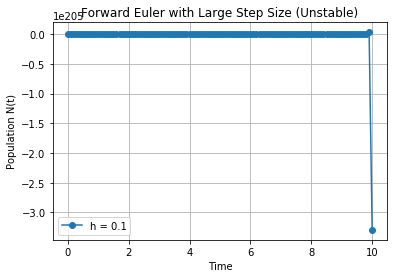

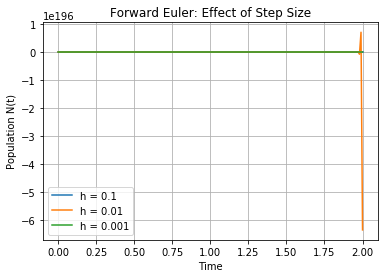

In [7]:
import numpy as np
import matplotlib.pyplot as plt

lam = 1000

# Define Equation
def g(t):
    return 1e9 * (1 + 0.5*np.sin(0.1*t))

def f(t, N):
    return -lam*N + g(t)

# Implement Forward Euler
def forward_euler(N0, t0, tf, h):
    t_vals = np.arange(t0, tf + h, h)
    N_vals = np.zeros_like(t_vals)
    N_vals[0] = N0
    
    for i in range(len(t_vals)-1):
        N_vals[i+1] = N_vals[i] + h*f(t_vals[i], N_vals[i])
    
    return t_vals, N_vals

# Initial Conditions
N0 = 1e5
t0 = 0
tf = 10

h = 0.1  # Large step size (should be unstable)

t_vals, N_vals = forward_euler(N0, t0, tf, h)

plt.plot(t_vals, N_vals, 'o-', label='h = 0.1')
plt.xlabel('Time')
plt.ylabel('Population N(t)')
plt.title('Forward Euler with Large Step Size (Unstable)')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate at decreasing step sizes
h_values = [0.1, 0.01, 0.001]

for h in h_values:
    t_vals, N_vals = forward_euler(N0, t0, 2, h)
    plt.plot(t_vals, N_vals, label=f'h = {h}')

plt.xlabel('Time')
plt.ylabel('Population N(t)')
plt.title('Forward Euler: Effect of Step Size')
plt.legend()
plt.grid(True)
plt.show()

To demonstrate stiffness, we have learned that you must implement Euler's Forward to show that it becomes unstable and/or requires tiny step size. This is exactly what happens above in the two graphs. For a large step size such as h=0.1 in this instance, the graph initially stable but then quickly diverges to large negative values. This still occurs when the step size is h=0.01. It is not until when teh step size is h=0.001, when the line does not completely become unstable and diverges.

This behavior occurs because the system contains a rapidly decaying term with λ = 1000. The stability condition for Forward Euler is:

$$
h < \frac{2}{\lambda} = 0.002
$$

These results confirm that the system is stiff, since explicit methods require extremely small step sizes for stability.

## Section 3: Mathematical Setup


### Residual Function

Using the Backward Euler method:

$$
N_{n+1} = N_n + h f(t_{n+1}, N_{n+1})
$$

For our model:

$$
f(t, N) = -\lambda N + g(t)
$$

Substitute into Backward Euler:

$$
N_{n+1} = N_n + h(-\lambda N_{n+1} + g(t_{n+1}))
$$

Rewriting so everything is on one side:

$$
F(N_{n+1}) = N_{n+1} - N_n - h(-\lambda N_{n+1} + g(t_{n+1})) = 0
$$

Simplifying:

$$
F(N_{n+1}) = N_{n+1} - N_n + h\lambda N_{n+1} - h g(t_{n+1})
$$

### Analytical Derivation of the Derivative

To apply Newton-Raphson, we compute:

$$
F'(N_{n+1}) = \frac{dF}{dN_{n+1}}
$$

Since $g(t)$ does not depend on $N$, we get:

$$
F'(N_{n+1}) = 1 + h\lambda
$$


### Newton-Raphson Update Formula

The Newton-Raphson method is given by:

$$
N^{(k+1)} = N^{(k)} - \frac{F(N^{(k)})}{F'(N^{(k)})}
$$

Substituting our expressions:

$$
N^{(k+1)} =
N^{(k)} -
\frac{
N^{(k)} - N_n + h\lambda N^{(k)} - h g(t_{n+1})
}{
1 + h\lambda
}
$$


### Simplification for Linear Form

For the linear equation:

$$
\frac{dN}{dt} = -\lambda N + g(t)
$$

the derivative:

$$
F'(N_{n+1}) = 1 + h\lambda
$$

is constant. This simplifies the Newton-Raphson method significantly, allowing it to converge very quickly (often in a single iteration).

Cite: Asked ChatGPT for help on mathematical setup and to double check calculations.

# Section 4: Implementation

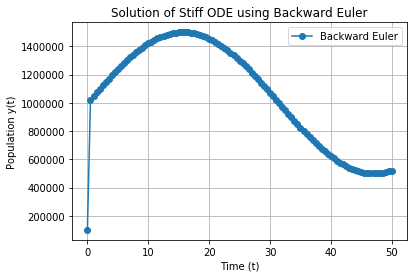

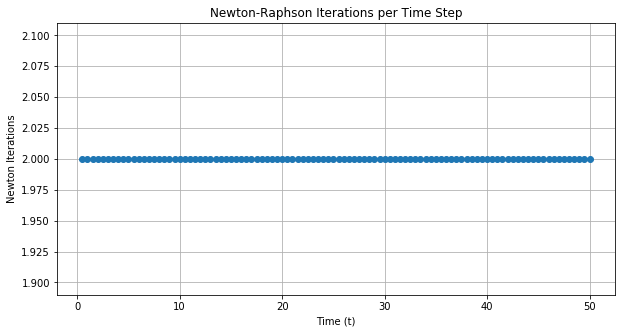

In [17]:
import numpy as np
import matplotlib.pyplot as plt

lam = 1000

# Function(t,y) defining ODE
def g(t):
    return 1e9 * (1 + 0.5*np.sin(0.1*t))

def f(t, y):
    return -lam * y + g(t)

def newton_raphson(g, dg, x0, tol=1e-6, max_iter=50):
    
    x = x0

    for i in range(max_iter):
        x_new = x - g(x) / dg(x)

        if abs(x_new - x) < tol:
            return x_new, i + 1
        
        x = x_new
        
    return None, max_iter

# Backward Euler method
def backward_euler(f, y0, t0, tf, h):
    
    t_values = np.arange(t0, tf + h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0    
    
    iterations = []
    
    for i in range(1, len(t_values)):
        
        t_next = t_values[i]
        y_prev = y_values[i - 1]    
        
    # Asked ChatGPT for help creating function and derivative
    
        # Residual function F(y_next) = 0
        F = lambda y_next: y_next - y_prev - h * f(t_next, y_next)

        # Derivative of residual (constant for this problem)
        dF = lambda y_next: 1 + h * lam

        # Initial guess: Forward Euler predictor
        y_guess = y_prev + h * f(t_values[i - 1], y_prev)

        # Solve using Newton-Raphson
        y_new, iters = newton_raphson(F, dF, y_guess)

        y_values[i] = y_new
        iterations.append(iters)

    return t_values, y_values, iterations

# Parameters
y0 = 1e5
t0 = 0
tf = 50
h = 0.5  # Larger Step Size

# Solve the ODE
t_values, y_values, iterations = backward_euler(f, y0, t0, tf, h)

# Plot the results
plt.plot(t_values, y_values, 'o-', label='Backward Euler')
plt.xlabel('Time (t)')
plt.ylabel('Population y(t)')
plt.title('Solution of Stiff ODE using Backward Euler')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.plot(t_values[1:], iterations, 'o-')
plt.xlabel('Time (t)')
plt.ylabel('Newton Iterations')
plt.title('Newton-Raphson Iterations per Time Step')
plt.grid(True)
plt.show()

# Section 5: Results and Analysis

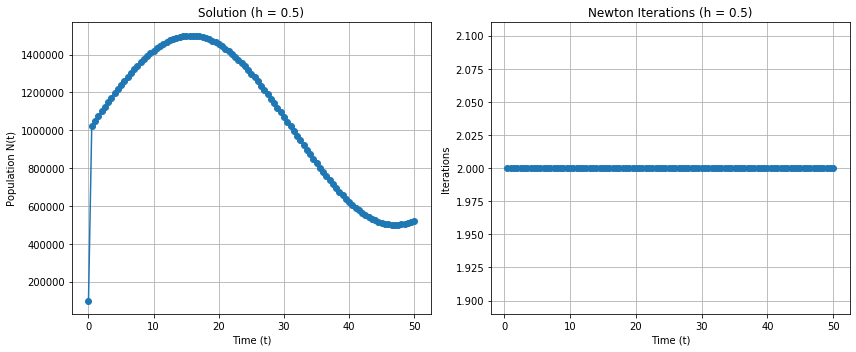

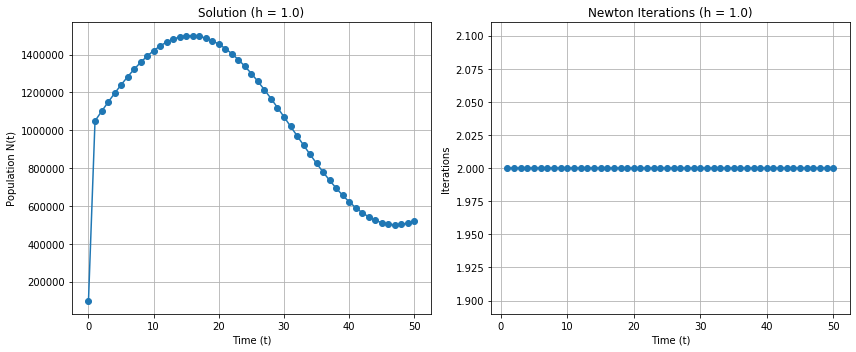

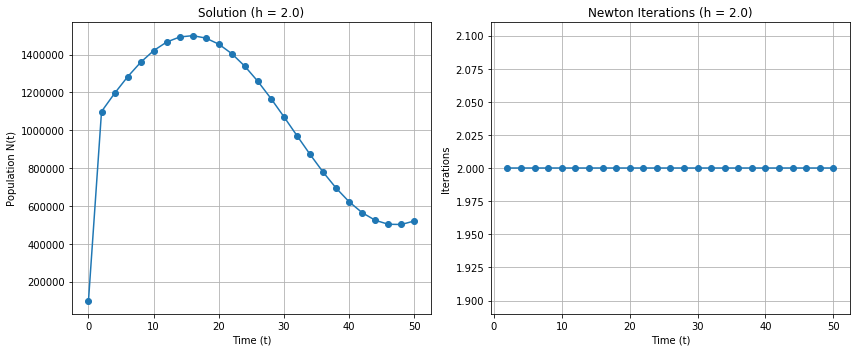

In [14]:
h_values = [0.5, 1.0, 2.0]

for h in h_values:
    t_vals, y_vals, iters = backward_euler(f, y0, t0, tf, h)
    
    fig, axs = plt.subplots(1, 2, figsize=(12,5))
    
    axs[0].plot(t_vals, y_vals, 'o-')
    axs[0].set_title(f'Solution (h = {h})')
    axs[0].set_xlabel('Time (t)')
    axs[0].set_ylabel('Population N(t)')
    axs[0].grid(True)
    
    axs[1].plot(t_vals[1:], iters, 'o-')
    axs[1].set_title(f'Newton Iterations (h = {h})')
    axs[1].set_xlabel('Time (t)')
    axs[1].set_ylabel('Iterations')
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
# Asked ChatGPT help form into smaller subplots to make length of document smaller

The plots above analyze three different step sizes including h=0.5,1.0 and 2.0. Each of the step sizes shows stability and consistentcy which shows that the Backward Euler Method is sufficient for stiff systems. While the larger step sizes do become a little more spaced out as fewer time points were used. However, they still follow the general trend of the solution very closely. 

# Section 6: Performance Analysis

In [16]:
h_values = [0.5, 1.0, 2.0]

print("Performance Analysis for Backward Euler")
print("h\tSteps\tAvg NR Iterations\tTotal NR Iterations")

for h in h_values:
    t_vals, y_vals, iters = backward_euler(f, y0, t0, tf, h)
    
    steps = len(t_vals) - 1
    avg_iters = np.mean(iters)
    total_iters = np.sum(iters)
    
    print(f"{h}\t{steps}\t{avg_iters:.2f}\t\t\t{total_iters}")

# Forward Euler Comparison
h_forward = 0.001
forward_steps = int((tf - t0) / h_forward)

print("\nForward Euler Stability Requirement")
print(f"Maximum stable h for Forward Euler: h < {2/lam}")
print(f"Chosen stable Forward Euler h: {h_forward}")
print(f"Number of Forward Euler steps needed: {forward_steps}")

Performance Analysis for Backward Euler
h	Steps	Avg NR Iterations	Total NR Iterations
0.5	100	2.00			200
1.0	50	2.00			100
2.0	25	2.00			50

Forward Euler Stability Requirement
Maximum stable h for Forward Euler: h < 0.002
Chosen stable Forward Euler h: 0.001
Number of Forward Euler steps needed: 50000


Looking at the computational cost for Forward Euler versus Backward Euler, the difference in number of steps is significantly bigger when using the Forward Euler Method. Additionally, Forward Euler requires the step size be extremely small to stay stable. With both of these cons being towards the Forward Euler Method, this shows that the Backward Euler Method is far more computationally efficient, at least in this case for stiff systems. 

# Section 7: Conclusions

This part of the project proves how using implicit methods is far more efficient and has multiple advantages for stiff ODEs. Backward Euler, an implicit method, remianed stable for multiple varying step sizes. Newton-Raphson iteration was used to solve the implicit equation at each step and converged quickly. On the other hand, Forward Euler was shown to quickly become unstable at very low step sizes, making it not reliable for certain models such as the one used for this project. Therfore, when solving stiff systems, implicit methods such as Backward Euler are perfect to confirm an accurate and stable solution.

Cite: In this project, I used ChatGPT to help explain what some math equations meant, ensured my code was correct, and overall make sure I completed what the assignment was asking for.